# Lab: Implement and evaluate a Neural Network for segmentation and object detection using COCO
Instructor: M.Sc. Mario Ivan Lopez Valdovinos

## Introduction
This project focuses on implementing and evaluating neural network models for object detection and instance segmentation using the COCO dataset. The models are trained to identify multiple object categories, locate them using bounding boxes, and generate pixel-level segmentation masks. Their performance is assessed using standard metrics such as precision, recall, Intersection over Union (IoU), and mean Average Precision (mAP).

## Step 1. Install Python, PyTorch, Ultralytics YOLO, and Matplotlib.
YOLO (You Only Look Once) is a single-stage detection model that unifies feature extraction and prediction within a deep neural network. For segmentation, it adds a head that predicts pixel-level masks using mask prototypes and coefficients. Ultralytics provides the most advanced and user-friendly implementation.

### 1.1: Imports

In [1]:
# System and path utilities
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version

import os
import sys
import random
import shutil

# Data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Deep Learning libraries
import torch
import yaml

### 1.2: Environment detection

In [2]:
# Detect environment and configure workspace
IS_COLAB = "google.colab" in sys.modules

# Install dependencies in Colab
if IS_COLAB:
    %pip install -q ultralytics==8.4.102

print(f"Execution Environment: {'Google Colab' if IS_COLAB else 'Local Workspace / VS Code'}")

Execution Environment: Local Workspace / VS Code


### 1.3 System information and reproducibility

In [3]:
# Reproducibility configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hardware and versions
DEVICE = "CUDA" if torch.cuda.is_available() else "CPU"

try:
    INSTALLED_ULTRALYTICS = version("ultralytics")
except PackageNotFoundError:
    INSTALLED_ULTRALYTICS = "not installed"

# Print system specs)
print(f"Target Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Random Seed: {SEED}")
print("-" * 60)
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Ultralytics version: {INSTALLED_ULTRALYTICS}")

Target Device: CUDA
GPU Name: NVIDIA GeForce RTX 3060
Random Seed: 42
------------------------------------------------------------
Python version: 3.11.15
NumPy version: 2.4.6
PyTorch version: 2.12.1
Ultralytics version: 8.4.115


## Step 2. Download the COCO dataset or use a smaller subset.
COCO (Common Objects in Context) is the gold standard for detection and segmentation, featuring 80 categories and over 200,000 annotated images. We use COCO128-seg, a subset of 128 images with segmentation annotations (polygons) that enable mask training, keeping the lab lightweight yet representative.

### 2.1: Workplace setup

In [4]:
# Workspace directory setup
if IS_COLAB:
    SESSION_WORKSPACE = Path("/content/yolo_coco_lab")
else:
    SESSION_WORKSPACE = Path.cwd() / "yolo_coco_lab"

SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)

### 2.2: COCO dataset download

In [5]:
# YOLO and COCO utilities
from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

# Configure datasets directory
SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
# Update Ultralytics settings to store datasets in our workspace
settings.update({"datasets_dir": str(SESSION_DATASETS)})

print(f"Workspace Path: {SESSION_WORKSPACE}")
print(f"Datasets Path:  {SESSION_DATASETS}")

# Download COCO128 Instance Segmentation Dataset
# Note: coco128-seg contains polygon annotations required for masks
dataset_info = check_det_dataset("coco128-seg.yaml", autodownload=True)
coco_root = Path(dataset_info["path"])

# Raw dataset paths
raw_images_dir = coco_root / "images" / "train2017"
raw_labels_dir = coco_root / "labels" / "train2017"

# Gather image files and match with labels
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
all_image_paths = sorted([
    p for p in raw_images_dir.glob("*") 
    if p.suffix.lower() in IMAGE_EXTENSIONS
])

Workspace Path: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab
Datasets Path:  /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab/datasets


### Step 3. Divide the dataset into:
- **70% training**
- **15% validation**
- **15% testing**

The three subsets must be separated before training so that the test images remain unseen until the final evaluation.

Because COCO images can contain **several object classes at the same time**, a simple `train_test_split(..., stratify=...)` is not appropriate unless each image is represented by only one class. Here we use a small deterministic greedy multi-label split: images are distributed while trying to preserve the frequency of each class in the three subsets. With only 128 images, the percentages are necessarily approximate and exact class proportions are not always possible.

The test set is used **only once, after training**, to estimate generalization to unseen images.


In [6]:
# Step 3.1: Create a deterministic multi-label stratified split

from collections import Counter

def get_image_classes(image_path):
    """Return the set of COCO class IDs present in one image."""
    label_path = raw_labels_dir / f"{image_path.stem}.txt"
    classes = set()

    if label_path.exists():
        for line in label_path.read_text().splitlines():
            parts = line.split()
            if parts:
                classes.add(int(float(parts[0])))

    return classes


# Each image may contain more than one class.
image_classes = {path: get_image_classes(path) for path in all_image_paths}

# Shuffle only once, using the fixed seed.
rng = random.Random(SEED)
images = all_image_paths.copy()
rng.shuffle(images)

# Target number of images in each split.
n = len(images)
n_train = round(n * 0.70)
n_val = round(n * 0.15)
n_test = n - n_train - n_val

split_sizes = {"train": n_train, "val": n_val, "test": n_test}
splits = {"train": [], "val": [], "test": []}

# Target class counts for each split.
class_counts = Counter(
    cls
    for classes in image_classes.values()
    for cls in classes
)
target_counts = {
    split: {
        cls: count * size / n
        for cls, count in class_counts.items()
    }
    for split, size in split_sizes.items()
}

# Process images containing rarer classes first.
images.sort(key=lambda p: (len(image_classes[p]), rng.random()), reverse=True)

for image_path in images:
    classes = image_classes[image_path]

    candidates = [
        split for split in split_sizes
        if len(splits[split]) < split_sizes[split]
    ]

    # Prefer the split whose current class counts are furthest below
    # its target distribution.
    def split_score(split):
        current = Counter(
            cls
            for p in splits[split]
            for cls in image_classes[p]
        )
        return sum(
            max(target_counts[split][cls] - current[cls], 0)
            for cls in classes
        )

    best_split = max(candidates, key=split_score)
    splits[best_split].append(image_path)

train_image_files = splits["train"]
val_image_files = splits["val"]
test_image_files = splits["test"]

print("-" * 60)
print(f"Total Dataset Images: {n}")
print(f" - Train Split (70%):      {len(train_image_files)} images")
print(f" - Validation Split (15%): {len(val_image_files)} images")
print(f" - Test Split (15%):       {len(test_image_files)} images")
print("-" * 60)


------------------------------------------------------------
Total Dataset Images: 128
 - Train Split (70%):      90 images
 - Validation Split (15%): 19 images
 - Test Split (15%):       19 images
------------------------------------------------------------


### Step 4. Prepare the annotations for:
- Object detection using **bounding boxes**
- Instance segmentation using **polygons**

YOLO annotation files use normalized coordinates:

- **Detection:** `class_id x_center y_center width height`
- **Segmentation:** `class_id x1 y1 x2 y2 ...`

For detection, the four coordinates describe the bounding box center, width, and height, all normalized to `[0, 1]`.

For segmentation, the remaining coordinates describe the vertices of the object's polygon, also normalized to `[0, 1]`. These polygons are converted internally into training masks.

The same segmentation label file can therefore provide the information needed by the segmentation model and the corresponding object location needed by the detection component.


### 4.1. Function to organize dataset splits.

The original COCO128-seg files are kept intact. We create separate `train`, `val`, and `test` folders and copy each image together with its matching annotation file.

Before copying, existing split folders are removed. This makes the notebook safe to run again without accumulating files from an earlier split.


In [7]:
def organize_dataset_split(split_name, image_list):
    """Create one YOLO split with its images and matching labels."""
    split_img_dir = coco_root / "images" / split_name
    split_lbl_dir = coco_root / "labels" / split_name

    # Remove an old split so that rerunning the notebook is reproducible.
    if split_img_dir.exists():
        shutil.rmtree(split_img_dir)
    if split_lbl_dir.exists():
        shutil.rmtree(split_lbl_dir)

    split_img_dir.mkdir(parents=True)
    split_lbl_dir.mkdir(parents=True)

    for img_path in image_list:
        shutil.copy2(img_path, split_img_dir / img_path.name)

        label_path = raw_labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            shutil.copy2(label_path, split_lbl_dir / label_path.name)
        else:
            # YOLO allows an empty label file for an image with no objects.
            (split_lbl_dir / f"{img_path.stem}.txt").touch()

    print(f"Split '{split_name}': {len(image_list)} images copied.")


### 4.2. Apply organization to all splits


In [8]:
organize_dataset_split("train", train_image_files)
organize_dataset_split("val", val_image_files)
organize_dataset_split("test", test_image_files)


Split 'train': 90 images copied.
Split 'val': 19 images copied.
Split 'test': 19 images copied.


### 4.3. Generate custom YAML configuration file

The YAML file tells Ultralytics where the three image subsets are located and provides the 80 COCO class names.

The `test` entry is important: it allows the final evaluation to use the held-out test images explicitly rather than accidentally evaluating on the validation set.


In [9]:
yaml_payload = {
    "path": coco_root.as_posix(),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": dataset_info["names"],
}

CUSTOM_YAML_PATH = SESSION_WORKSPACE / "coco_custom.yaml"

with open(CUSTOM_YAML_PATH, "w") as f:
    yaml.safe_dump(yaml_payload, f, sort_keys=False)

print(f"Custom YAML created at: {CUSTOM_YAML_PATH}")
print("Train, validation, and test annotations are ready.")


Custom YAML created at: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab/coco_custom.yaml
Train, validation, and test annotations are ready.


### Step 5. Load a pretrained YOLO detection model.

We use **YOLOv8n**, the nano version of YOLOv8, pretrained on COCO. Transfer learning starts from features learned from a much larger dataset instead of training from random weights.

This model performs **object detection**, not image classification: for every detected object it predicts a class, a confidence score, and a bounding box.

The distinction is important:

- **Classification:** one or more class labels for an image, without locating individual objects.
- **Detection:** class + confidence + bounding box for each object.
- **Instance segmentation:** class + confidence + bounding box + pixel mask for each object.

The present lab is therefore a **detection and instance-segmentation** lab.


In [10]:
det_model = YOLO("yolov8n.pt")

print(f"Model task: {det_model.task}")
print(f"Number of classes: {len(det_model.names)}")


Model task: detect
Number of classes: 80


### Step 6. Train the detection model using the training dataset.

The pretrained model is fine-tuned using the 70% training split. The validation split is used by Ultralytics during training to monitor performance.

For YOLOv8 detection, the training objective includes terms related to:

- **Box loss:** improves localization of bounding boxes.
- **Classification loss:** improves the predicted object class.
- **DFL (Distribution Focal Loss):** refines the localization of box boundaries.

Ten epochs are used here as a **teaching/experimental budget** because the dataset contains only 128 images. Ten epochs should not be interpreted as a guarantee of convergence or optimal performance.


In [11]:
print("Training detection model...")

det_model.train(
    data=str(CUSTOM_YAML_PATH),
    epochs=10,
    imgsz=640,
    batch=16,
    seed=SEED,
    project=str(SESSION_WORKSPACE / "runs"),
    name="yolo_detection_exp",
    exist_ok=True,
    verbose=False,
)

DET_BEST = SESSION_WORKSPACE / "runs" / "yolo_detection_exp" / "weights" / "best.pt"

print(f"Best detection weights: {DET_BEST}")


Training detection model...
New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab/coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

### Step 7. Load a pretrained YOLO segmentation model.

The segmentation model, `yolov8n-seg.pt`, extends YOLOv8 with an **instance-segmentation head**.

In addition to the detection information, the model predicts a mask for each detected object. YOLOv8-seg uses mask prototypes and instance-specific coefficients to construct the final masks.

This is different from semantic segmentation: the goal here is to distinguish **individual objects**, even when two objects belong to the same class.


In [12]:
seg_model = YOLO("yolov8n-seg.pt")

print(f"Model task: {seg_model.task}")
print(f"Number of classes: {len(seg_model.names)}")


Model task: segment
Number of classes: 80


### Step 8. Train the segmentation model using the same dataset partitions.

The segmentation model is trained independently from the detection-only model, using the same train/validation/test partition so that the comparison is fair.

Its objective includes the usual detection components plus a **mask loss**, which compares predicted instance masks with the ground-truth masks obtained from the annotated polygons.

The segmentation model shares the general YOLO feature-extraction/detection structure, but it has an additional segmentation head. The detection and segmentation models in this lab are **not trained jointly**; they are two separate pretrained models fine-tuned on the same dataset.


In [13]:
print("Training segmentation model...")

seg_model.train(
    data=str(CUSTOM_YAML_PATH),
    epochs=10,
    imgsz=640,
    batch=16,
    seed=SEED,
    project=str(SESSION_WORKSPACE / "runs"),
    name="yolo_segmentation_exp",
    exist_ok=True,
    verbose=False,
)

SEG_BEST = SESSION_WORKSPACE / "runs" / "yolo_segmentation_exp" / "weights" / "best.pt"

print(f"Best segmentation weights: {SEG_BEST}")


Training segmentation model...
New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab/coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.

### Step 9. Evaluate both models using the test dataset.

The test set contains images that were not used to update the model weights and were not used for hyperparameter selection.

To make the final evaluation explicit, we load the **best checkpoint** from each training run and evaluate it with `split="test"`.

For detection and segmentation we report:

- **mAP@0.50:** mean Average Precision at IoU = 0.50.
- **mAP@0.50:0.95:** mean Average Precision averaged over IoU thresholds from 0.50 to 0.95 in steps of 0.05.

The second metric is stricter because a prediction must localize the object more accurately to count as a good match.


In [14]:
# Load the best checkpoints saved during training.
det_best_model = YOLO(str(DET_BEST))
seg_best_model = YOLO(str(SEG_BEST))

print("Evaluating detection model on the test set...")
det_test_metrics = det_best_model.val(
    data=str(CUSTOM_YAML_PATH),
    split="test",
    verbose=False,
)

print("Evaluating segmentation model on the test set...")
seg_test_metrics = seg_best_model.val(
    data=str(CUSTOM_YAML_PATH),
    split="test",
    verbose=False,
)

print("Test evaluation completed.")


Evaluating detection model on the test set...
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 295.5±113.3 MB/s, size: 44.9 KB)
val: Scanning /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg/labels/test... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 2.3Kit/s 0.0s
val: New cache created: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.1it/s 0.7s1.7s
                   all         19         75      0.724      0.675      0.795      0.651
Speed: 2.2ms preprocess, 24.4ms inference, 0.0ms loss, 0.9ms postprocess p

### Step 10. Record the following detection metrics:

- **Precision:** `TP / (TP + FP)` — among the predicted objects, how many are correct?
- **Recall:** `TP / (TP + FN)` — among the real objects, how many were detected?
- **F1-score:** harmonic mean of precision and recall.
- **mAP@0.50:** mean Average Precision at IoU = 0.50.
- **mAP@0.50:0.95:** mean Average Precision over IoU thresholds from 0.50 to 0.95.

Precision and recall describe different aspects of detection quality. F1 summarizes their balance, while mAP summarizes the precision-recall behavior across confidence thresholds and classes.


In [15]:
det_precision = float(det_test_metrics.box.mp)
det_recall = float(det_test_metrics.box.mr)
det_f1 = (
    2 * det_precision * det_recall / (det_precision + det_recall)
    if det_precision + det_recall > 0 else 0.0
)
det_map50 = float(det_test_metrics.box.map50)
det_map50_95 = float(det_test_metrics.box.map)

print("\n" + "=" * 60)
print("DETECTION METRICS — TEST SET")
print("=" * 60)
print(f"Precision:       {det_precision:.4f}")
print(f"Recall:          {det_recall:.4f}")
print(f"F1-score:        {det_f1:.4f}")
print(f"mAP@0.50:        {det_map50:.4f}")
print(f"mAP@0.50:0.95:   {det_map50_95:.4f}")
print("=" * 60)



DETECTION METRICS — TEST SET
Precision:       0.7237
Recall:          0.6754
F1-score:        0.6987
mAP@0.50:        0.7953
mAP@0.50:0.95:   0.6505


### Step 11. Record the following segmentation metrics:

- **Mask precision**
- **Mask recall**
- **Mask mAP@0.50**
- **Mask mAP@0.50:0.95**
- **Mask IoU**
- **Dice coefficient**

For two binary masks, the metrics are:

$$
IoU = \frac{|A \cap B|}{|A \cup B|}
$$

and

$$
Dice = \frac{2|A \cap B|}{|A| + |B|}.
$$

Here we calculate IoU and Dice at the **instance level**. This is important because instance segmentation predicts one mask per object. Simply combining all predicted masks into one large binary mask would lose the correspondence between individual objects.

For each test image, predicted masks are matched to ground-truth masks of the same class using their mask IoU. Unmatched ground-truth objects and unmatched predictions receive a score of zero, so missed objects and false-positive instances are not hidden.

The predicted polygon coordinates returned by `results.masks.xy` are already expressed in the original image coordinate system. Therefore, we do not need to manually resize the low-resolution mask tensor to 640×640 and then back to the original image.


In [16]:
def polygon_to_mask(polygon, image_shape):
    """Convert polygon vertices in pixel coordinates to a binary mask."""
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    points = np.asarray(polygon, dtype=np.int32).reshape(-1, 1, 2)
    if len(points) >= 3:
        cv2.fillPoly(mask, [points], 1)

    return mask.astype(bool)


def mask_iou(mask_a, mask_b):
    """IoU between two binary masks."""
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    return intersection / union if union else 0.0


def mask_dice(mask_a, mask_b):
    """Dice coefficient between two binary masks."""
    intersection = np.logical_and(mask_a, mask_b).sum()
    total = mask_a.sum() + mask_b.sum()
    return 2 * intersection / total if total else 0.0


def read_ground_truth_masks(label_path, image_shape):
    """Read segmentation polygons and class IDs from a YOLO label file."""
    masks, classes = [], []

    if not label_path.exists():
        return masks, classes

    for line in label_path.read_text().splitlines():
        parts = line.split()

        # Segmentation labels contain class_id + at least 3 polygon points.
        if len(parts) < 7:
            continue

        cls = int(float(parts[0]))
        coords = np.asarray(parts[1:], dtype=float).reshape(-1, 2)

        h, w = image_shape[:2]
        polygon = coords * np.array([w, h])

        masks.append(polygon_to_mask(polygon, image_shape))
        classes.append(cls)

    return masks, classes


def match_instance_masks(gt_masks, gt_classes, pred_masks, pred_classes):
    """Greedily match masks of the same class using maximum IoU."""
    pairs = []
    used_predictions = set()

    # Match each ground-truth instance with its best unused prediction.
    for gt_index, gt_mask in enumerate(gt_masks):
        candidates = [
            pred_index
            for pred_index, cls in enumerate(pred_classes)
            if cls == gt_classes[gt_index] and pred_index not in used_predictions
        ]

        if not candidates:
            pairs.append((gt_index, None, 0.0))
            continue

        best_pred = max(
            candidates,
            key=lambda i: mask_iou(gt_mask, pred_masks[i])
        )
        best_iou = mask_iou(gt_mask, pred_masks[best_pred])

        used_predictions.add(best_pred)
        pairs.append((gt_index, best_pred, best_iou))

    return pairs, used_predictions


# Metrics supplied directly by Ultralytics.
mask_precision = float(seg_test_metrics.seg.mp)
mask_recall = float(seg_test_metrics.seg.mr)
mask_map50 = float(seg_test_metrics.seg.map50)
mask_map50_95 = float(seg_test_metrics.seg.map)

test_image_paths = sorted((coco_root / "images" / "test").glob("*.jpg"))

iou_scores = []
dice_scores = []

for image_path in test_image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        continue

    image_shape = image.shape

    # Ground truth
    label_path = coco_root / "labels" / "test" / f"{image_path.stem}.txt"
    gt_masks, gt_classes = read_ground_truth_masks(label_path, image_shape)

    # Prediction masks are returned in original-image coordinates by masks.xy.
    result = seg_best_model.predict(
        source=str(image_path),
        imgsz=640,
        conf=0.25,
        verbose=False,
    )[0]

    pred_masks = []
    pred_classes = []

    if result.masks is not None and result.boxes is not None:
        pred_classes = result.boxes.cls.int().cpu().tolist()

        for polygon in result.masks.xy:
            pred_masks.append(polygon_to_mask(polygon, image_shape))

    pairs, used_predictions = match_instance_masks(
        gt_masks, gt_classes, pred_masks, pred_classes
    )

    # Penalize missed ground-truth instances.
    for gt_index, pred_index, _ in pairs:
        if pred_index is None:
            iou_scores.append(0.0)
            dice_scores.append(0.0)
        else:
            iou_scores.append(mask_iou(gt_masks[gt_index], pred_masks[pred_index]))
            dice_scores.append(mask_dice(gt_masks[gt_index], pred_masks[pred_index]))

    # Penalize false-positive predicted instances.
    for pred_index in range(len(pred_masks)):
        if pred_index not in used_predictions:
            iou_scores.append(0.0)
            dice_scores.append(0.0)

mean_iou = float(np.mean(iou_scores)) if iou_scores else 0.0
mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0

print("\n" + "=" * 60)
print("SEGMENTATION METRICS — TEST SET")
print("=" * 60)
print(f"Mask Precision:      {mask_precision:.4f}")
print(f"Mask Recall:         {mask_recall:.4f}")
print(f"Mask mAP@0.50:       {mask_map50:.4f}")
print(f"Mask mAP@0.50:0.95:  {mask_map50_95:.4f}")
print(f"Mean mask IoU:       {mean_iou:.4f}")
print(f"Mean Dice:           {mean_dice:.4f}")
print("=" * 60)

if iou_scores:
    print(f"\nIoU range:  {min(iou_scores):.4f} – {max(iou_scores):.4f}")
    print(f"Dice range: {min(dice_scores):.4f} – {max(dice_scores):.4f}")



SEGMENTATION METRICS — TEST SET
Mask Precision:      0.6990
Mask Recall:         0.6325
Mask mAP@0.50:       0.7232
Mask mAP@0.50:0.95:  0.5535
Mean mask IoU:       0.3879
Mean Dice:           0.4257

IoU range:  0.0000 – 0.9588
Dice range: 0.0000 – 0.9790


### Step 12. Display several test images with:
- Ground-truth annotations
- Predicted bounding boxes
- Predicted instance masks
- Confidence scores

Qualitative evaluation complements the numerical metrics. It allows us to inspect:

- missed objects (**false negatives**),
- incorrect detections (**false positives**),
- inaccurate bounding boxes,
- masks that do not follow the object boundary,
- difficult cases such as small or partially occluded objects.

The three panels below use the same test image: **Ground Truth**, **Detection**, and **Instance Segmentation**.


Total test images: 19
Selected images:   3
000000000009.jpg: GT=8, detections=7, masks=6
000000000036.jpg: GT=2, detections=2, masks=2
000000000077.jpg: GT=8, detections=8, masks=4


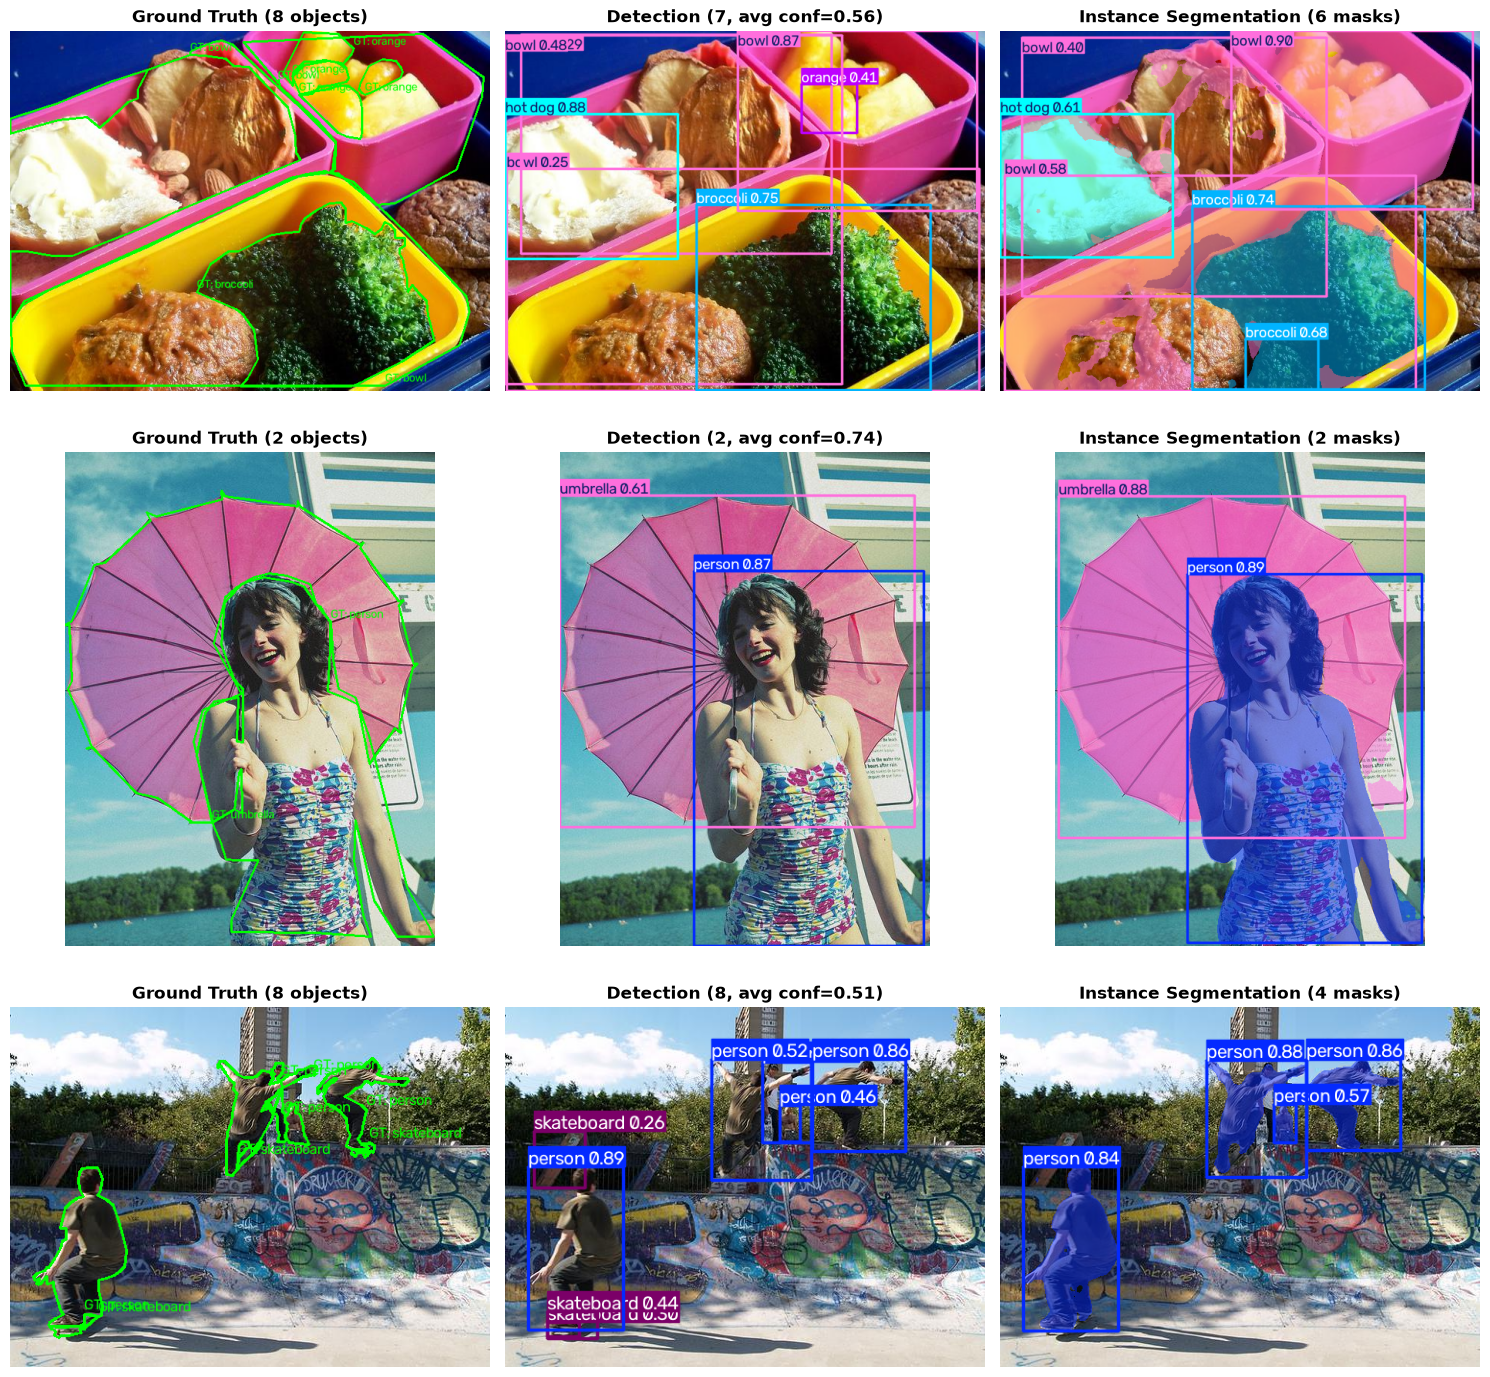

------------------------------------------------------------
Visualization saved to: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Coco/yolo_coco_lab/test_visualizations.png
------------------------------------------------------------


In [17]:
%matplotlib inline

test_img_dir = coco_root / "images" / "test"
test_lbl_dir = coco_root / "labels" / "test"

test_images = sorted(test_img_dir.glob("*.jpg"))

# Select up to three test images with annotations.
annotated_images = [
    p for p in test_images
    if (test_lbl_dir / f"{p.stem}.txt").exists()
    and (test_lbl_dir / f"{p.stem}.txt").stat().st_size > 0
]

selected_images = annotated_images[:3] or test_images[:3]

print(f"Total test images: {len(test_images)}")
print(f"Selected images:   {len(selected_images)}")


def draw_ground_truth(image, label_path):
    """Draw YOLO ground-truth boxes and segmentation polygons."""
    output = image.copy()
    h, w = output.shape[:2]
    count = 0

    if not label_path.exists():
        return output, count

    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))
        name = dataset_info["names"][cls]

        if len(parts) == 5:
            # Bounding-box annotation.
            _, xc, yc, bw, bh = map(float, parts)

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                output, f"GT: {name}", (x1, max(15, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1
            )
            count += 1

        else:
            # Segmentation polygon.
            coords = np.asarray(parts[1:], dtype=float).reshape(-1, 2)
            points = (coords * np.array([w, h])).astype(np.int32)
            points = points.reshape(-1, 1, 2)

            if len(points) >= 3:
                cv2.polylines(output, [points], True, (0, 255, 0), 2)
                x, y = points[0, 0]
                cv2.putText(
                    output, f"GT: {name}", (int(x), max(15, int(y) - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1
                )
                count += 1

    return output, count


fig, axes = plt.subplots(
    len(selected_images), 3,
    figsize=(15, 5 * len(selected_images)),
    squeeze=False
)

for row, image_path in enumerate(selected_images):
    image = cv2.imread(str(image_path))
    label_path = test_lbl_dir / f"{image_path.stem}.txt"

    # Ground truth
    gt_image, gt_count = draw_ground_truth(image, label_path)

    # Detection
    det_result = det_best_model.predict(
        source=str(image_path), conf=0.25, verbose=False
    )[0]
    det_image = det_result.plot()

    # Segmentation
    seg_result = seg_best_model.predict(
        source=str(image_path), conf=0.25, verbose=False
    )[0]
    seg_image = seg_result.plot()

    # Detection information
    det_count = len(det_result.boxes) if det_result.boxes is not None else 0
    det_conf = (
        float(det_result.boxes.conf.mean())
        if det_count else 0.0
    )

    # Segmentation information
    mask_count = len(seg_result.masks) if seg_result.masks is not None else 0

    panels = [
        (gt_image, f"Ground Truth ({gt_count} objects)"),
        (det_image, f"Detection ({det_count}, avg conf={det_conf:.2f})"),
        (seg_image, f"Instance Segmentation ({mask_count} masks)"),
    ]

    for col, (panel, title) in enumerate(panels):
        axes[row, col].imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB))
        axes[row, col].set_title(title, fontweight="bold")
        axes[row, col].axis("off")

    print(
        f"{image_path.name}: "
        f"GT={gt_count}, detections={det_count}, masks={mask_count}"
    )

plt.tight_layout()

output_path = SESSION_WORKSPACE / "test_visualizations.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()

print("-" * 60)
print(f"Visualization saved to: {output_path}")
print("-" * 60)
